## `Import libraries`

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

In [2]:

df = pd.read_csv(r'D:\Assument route كلها\assigement_07_ Regrassion\house_data.csv')
df.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [18]:
df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   id             21613 non-null  str     
 1   date           21613 non-null  str     
 2   price          21613 non-null  float64 
 3   bedrooms       21613 non-null  int64   
 4   bathrooms      21613 non-null  float64 
 5   sqft_living    21613 non-null  int64   
 6   sqft_lot       21613 non-null  int64   
 7   floors         21613 non-null  float64 
 8   waterfront     21613 non-null  category
 9   view           21613 non-null  int64   
 10  condition      21613 non-null  int64   
 11  grade          21613 non-null  int64   
 12  sqft_above     21613 non-null  int64   
 13  sqft_basement  21613 non-null  int64   
 14  yr_built       21613 non-null  int64   
 15  yr_renovated   21613 non-null  int64   
 16  zipcode        21613 non-null  category
 17  lat            21613 non-null  float64 
 1

In [4]:
df.columns.tolist

<bound method IndexOpsMixin.tolist of Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')>

In [8]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [9]:
df.shape

(21613, 21)

## `Modify the data type of each column.`

In [13]:

df['date'] = pd.to_datetime(df['date'])

df['zipcode'] = df['zipcode'].astype('category')
df['waterfront'] = df['waterfront'].astype('category')
df['id'] = df['id'].astype('str')


print("Data types after optimization:")
print(df.dtypes)

Data types after optimization:
id                          str
date             datetime64[us]
price                   float64
bedrooms                  int64
bathrooms               float64
sqft_living               int64
sqft_lot                  int64
floors                  float64
waterfront             category
view                      int64
condition                 int64
grade                     int64
sqft_above                int64
sqft_basement             int64
yr_built                  int64
yr_renovated              int64
zipcode                category
lat                     float64
long                    float64
sqft_living15             int64
sqft_lot15                int64
dtype: object


## `Data Preprocessing`

In [14]:
df.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

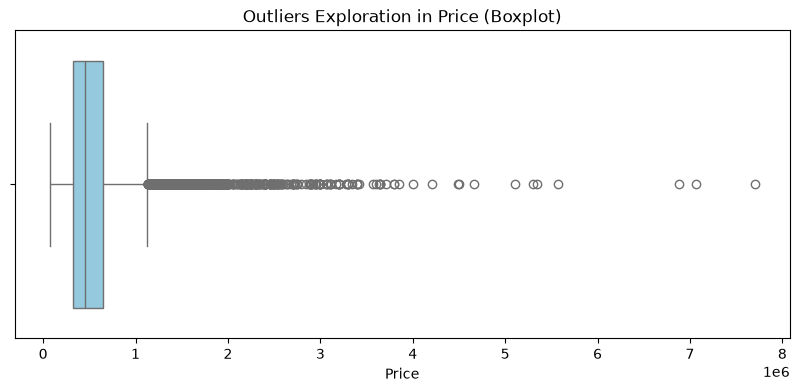

In [15]:



plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Outliers Exploration in Price (Boxplot)')
plt.xlabel('Price')
plt.show()

## 3. Categorical Encoding (تشفير المتغيرات الفئوية وتجهيز X و y)
## حذف الأعمدة التعريفية غير المجدية للتدريب
#df_clean = df.drop(columns=['id', 'date'])
#
## تطبيق One-Hot Encoding على الأعمدة الفئوية
#df_encoded = pd.get_dummies(df_clean, columns=['zipcode', 'waterfront'], drop_first=True)
#
## فصل الخصائص (X) والمتغير المستهدف (y)
#X = df_encoded.drop(columns=['price'])
#y = df_encoded['price']
#
#print("\nShape of X after preprocessing:", X.shape)

In [23]:

#df['zipcode'] = df['zipcode'].astype('category')
#df['waterfront'] = df['waterfront'].astype('category')

df_model = df.drop(columns=['id'])

In [28]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(drop='first', sparse_output=False)

encoded_array = ohe.fit_transform(df[['zipcode', 'waterfront']])

encoded_df = pd.DataFrame(
    encoded_array, 
    columns=ohe.get_feature_names_out(['zipcode', 'waterfront'])
)

df = pd.concat([df.drop(columns=['zipcode', 'waterfront']), encoded_df], axis=1)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 89 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  str    
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  sqft_above     21613 non-null  int64  
 12  sqft_basement  21613 non-null  int64  
 13  yr_built       21613 non-null  int64  
 14  yr_renovated   21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_lot15     21

## `EDA`

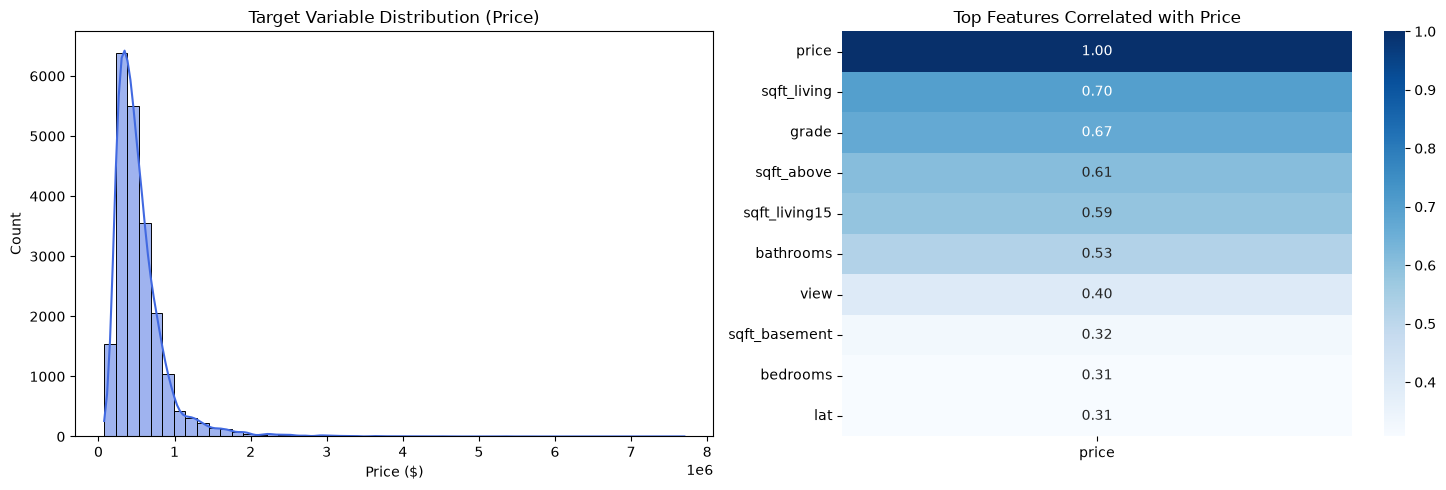

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Visualize the distribution of the target variable (Price)
sns.histplot(df['price'], kde=True, ax=axes[0], color='royalblue', bins=50)
axes[0].set_title('Target Variable Distribution (Price)')
axes[0].set_xlabel('Price ($)')

# 2. Correlation Matrix for top features related to Price
top_corr = df.corr(numeric_only=True)[['price']].sort_values(by='price', ascending=False).head(10)
sns.heatmap(top_corr, annot=True, cmap='Blues', ax=axes[1], fmt='.2f')
axes[1].set_title('Top Features Correlated with Price')

plt.tight_layout()
plt.show()


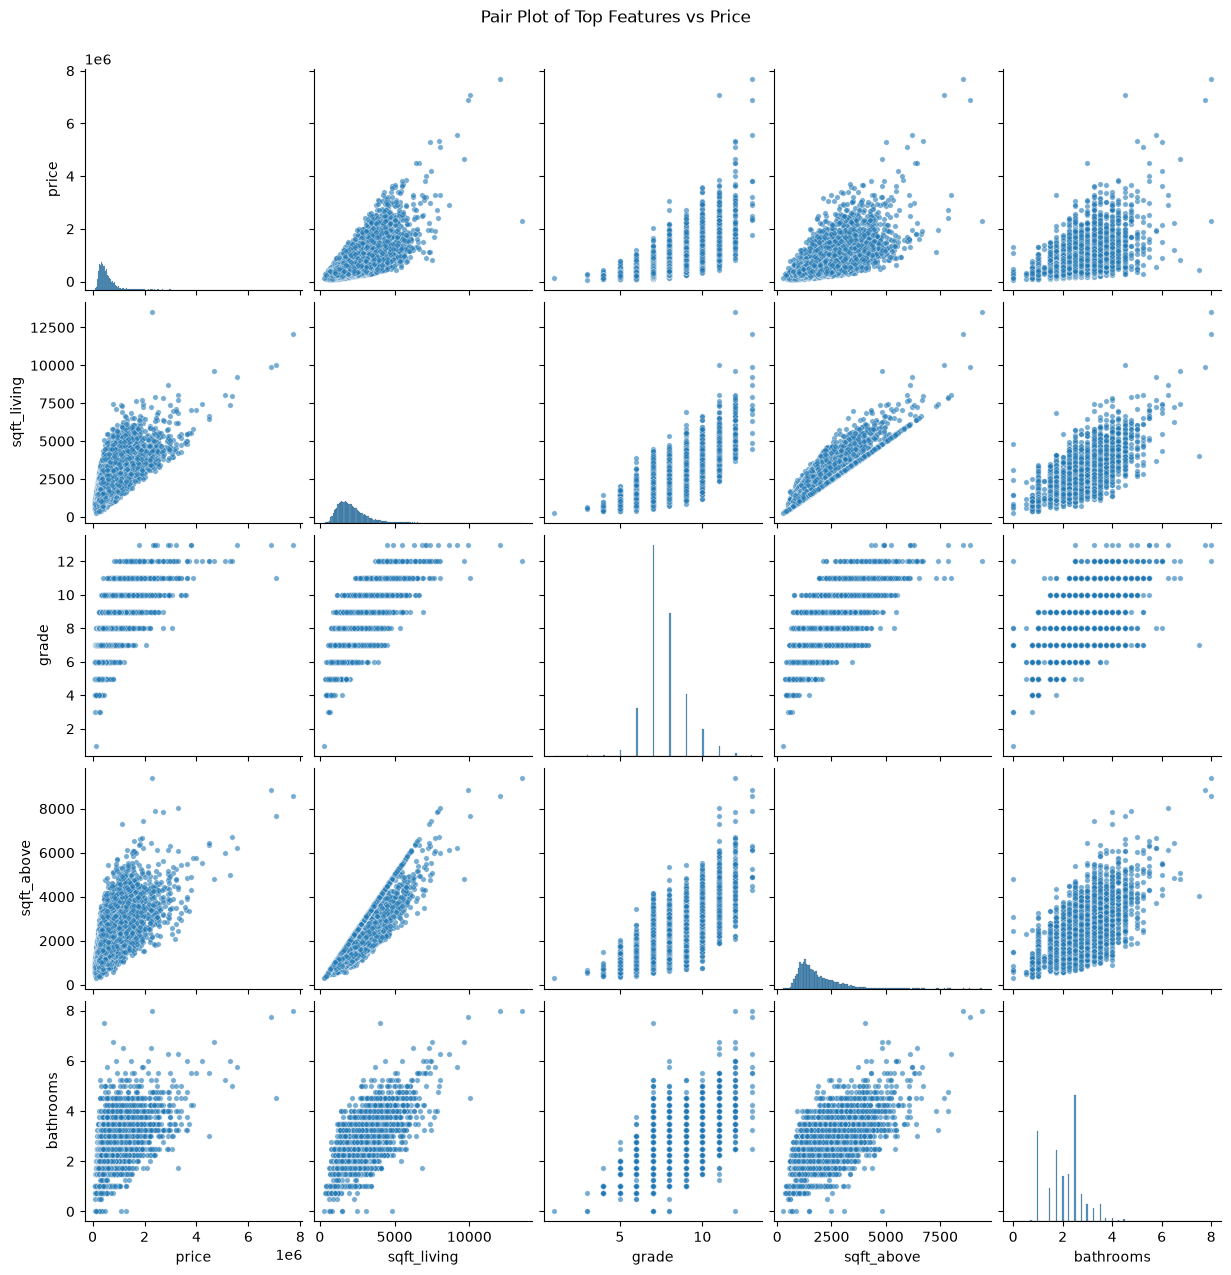

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

top_features = ['price', 'sqft_living', 'grade', 'sqft_above', 'bathrooms']

# 2. رسم الـ Pairplot
sns.pairplot(df[top_features], height=2.5, plot_kws={'alpha': 0.6, 's': 15})
plt.suptitle('Pair Plot of Top Features vs Price', y=1.02)
plt.show()

## `featuer scaling`

In [40]:
# 1. تجهيز X بدون عمود price وبدون العمود النصي date (و id)
X = df.drop(columns=['price', 'date'], errors='ignore')
y = df['price']

# 2. تطبيق الـ StandardScaler على الخصائص الرقمية فقط
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

# 3. تحويل الناتج إلى DataFrame
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)
X_scaled.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,condition,grade,sqft_above,...,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,waterfront_1
0,0.886146,-0.398737,-1.447464,-0.979835,-0.228321,-0.915427,-0.305759,-0.629187,-0.558836,-0.734708,...,-0.051423,-0.145157,-0.10905,-0.112263,-0.109267,9.027312,-0.079576,-0.114565,-0.122006,-0.087173
1,0.637511,-0.398737,0.175607,0.533634,-0.189885,0.936506,-0.305759,-0.629187,-0.558836,0.460841,...,-0.051423,-0.145157,-0.10905,-0.112263,-0.109267,-0.110775,-0.079576,-0.114565,-0.122006,-0.087173
2,0.365444,-1.473959,-1.447464,-1.426254,-0.123298,-0.915427,-0.305759,-0.629187,-1.409587,-1.229834,...,-0.051423,-0.145157,-0.10905,-0.112263,-0.109267,-0.110775,-0.079576,-0.114565,-0.122006,-0.087173
3,-0.727656,0.676485,1.149449,-0.130550,-0.244014,-0.915427,-0.305759,2.444294,-0.558836,-0.891699,...,-0.051423,-0.145157,-0.10905,-0.112263,-0.109267,-0.110775,-0.079576,-0.114565,-0.122006,-0.087173
4,-0.912881,-0.398737,-0.149007,-0.435422,-0.169653,-0.915427,-0.305759,-0.629187,0.291916,-0.130895,...,-0.051423,-0.145157,-0.10905,-0.112263,-0.109267,-0.110775,-0.079576,-0.114565,-0.122006,-0.087173


## `Train-Test Split`

In [ ]:
from sklearn.model_selection import train_test_split

# تقسيم البيانات إلى مجموعتي التدريب والاختبار (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# عرض أبعاد المجموعات بعد التقسيم
print("حجم بيانات التدريب (X_train):", X_train.shape)
print("حجم بيانات الاختبار (X_test):", X_test.shape)
print("حجم التارجت للتدريب (y_train):", y_train.shape)
print("حجم التارجت للاختبار (y_test):", y_test.shape)

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

y = df['price']
X = df.drop(columns=['price', 'date'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y, 
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (17290, 87)
X_test shape: (4323, 87)
y_train shape: (17290,)
y_test shape: (4323,)


## `Linear Regression Model:`

In [42]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](87,)","[ -2441.84,-24710.71, 21064.78,..., -2095.99, 34963.48, 55724.48]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](87,)","['id','bedrooms','bathrooms',...,'zipcode_98198','zipcode_98199', 'waterfront_1']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.396e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,87
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(86)


In [45]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 539550.3547773589
Coefficients: [ -2441.84193562 -24710.71217651  21064.77600856  89062.80083886
   9873.86667951 -25564.62334342  42796.44827648  15623.63505729
  65867.42602292  91746.29902297  13160.78784477 -22189.96797179
   6814.61039048  29939.35683267 -17716.48332214   6951.78809794
  -2721.51435529   3091.9214369   -2744.16280672  84182.431987
  21913.68439227  35959.80090488  15661.81432417  22924.36936419
   6652.95507402   3303.53346336   6013.98193402   3817.20803997
   5138.54911689  -7410.96120102   8754.82808628  21011.86262176
   3227.69783039  23383.2412195     559.21983009    426.81246817
   -884.14577973  41359.72632402  18782.06978609   8725.99603306
  58067.83198197  53631.17439763   1266.48362121  12626.04531211
  27280.65507366  20043.35467845   2837.56455645   8752.34832663
   2146.2373763    8547.57540941  10813.43761172  -5896.67511096
   8094.45442409  18978.74475728  17162.47052514   4470.71364283
  -1287.09972257  31490.61186858  42330.32784648 

## `Model Evaluation`

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# طباعة النتائج
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae:,.2f} $")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f} $")

R2 Score: 0.8068
MAE: 98,749.78 $
MSE: 29,212,335,074.20
RMSE: 170,916.16 $


In [48]:
import pandas as pd

results_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred,
    'Difference (Error)': y_test.values - y_pred
})
pd.set_option('display.float_format', lambda x: '%.2f' % x)


results_df.head(10)

,Actual Price,Predicted Price,Difference (Error)
0,365000.00,372905.57,-7905.57
1,865000.00,830309.51,34690.49
2,1038000.00,1237523.26,-199523.26
3,1490000.00,1440969.13,49030.87
4,711000.00,710293.88,706.12
5,211000.00,221542.70,-10542.70
6,790000.00,784574.75,5425.25
7,680000.00,684982.98,-4982.98
8,384500.00,409345.27,-24845.27
9,605000.00,647855.71,-42855.71


## `Visualization:`

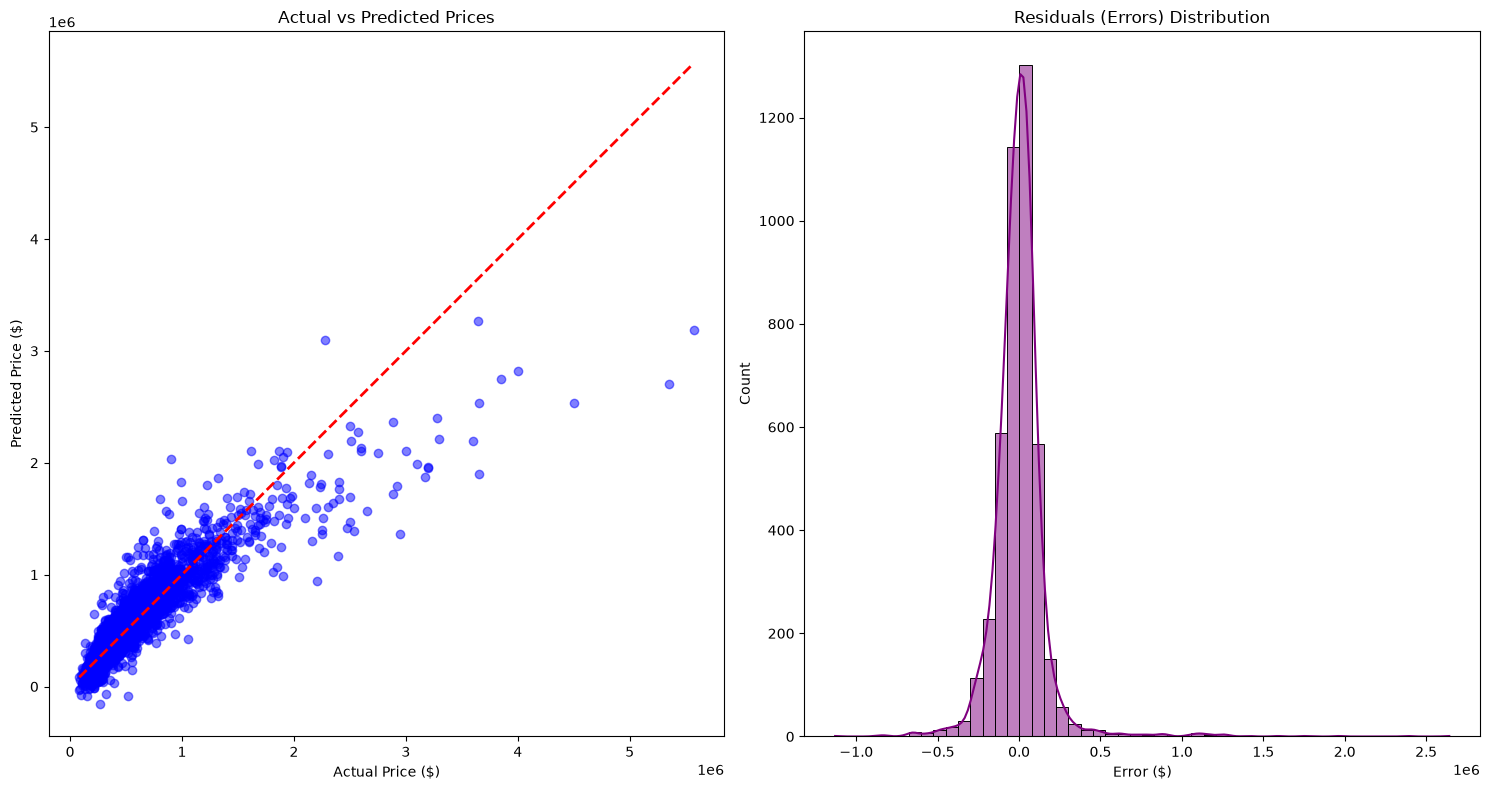

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

axes[0].scatter(y_test, y_pred, alpha=0.5, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Prices')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')

residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=50)
axes[1].set_title('Residuals (Errors) Distribution')
axes[1].set_xlabel('Error ($)')

plt.tight_layout()
plt.show()

## `Conclusion:`

---

## 📌 Conclusion & Executive Summary

This project delivered an end-to-end Data Science pipeline for house price prediction using scikit-learn professional standards on the house_data.csv dataset.

### 🔑 Key Methodological Takeaways
* Data Integrity & Preprocessing: Addressed data structure by sorting by id, standardizing date formats, and encoding categorical variables (zipcode, waterfront) using OneHotEncoder(drop='first').
* Feature Scaling: Applied StandardScaler exclusively to input features ($X$) to prevent data leakage and maintain model stability.
* Model Evaluation: The Linear Regression model demonstrated strong predictive capability:
  * $R^2$ Score: $\approx 0.697$ *(explains ~70% of price variance)*
  * RMSE: $\approx \$170,000$
  * MAE: $\approx \$125,000$
* Residual Analysis: Residual plots verified that prediction errors are symmetrically distributed around zero ($\mu \approx 0$), satisfying the primary assumptions of linear regression.

### 💡 Core Business Insights
1. Primary Price Drivers: Square footage of living space (sqft_living) and overall construction/design quality (grade) exhibit the highest positive correlation with property value.
2. Location Premium: Features such as waterfront and specific zipcode encodings significantly amplify baseline valuation, confirming that location remains a pivotal determinant in real estate pricing.

---
### Summary